# Mental Health Predictions

This jupyter notebook will help us analyze anbd clean the data of our mental health sample.

In [11]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
#cleaning data
sample = pd.read_csv("playground-series-s4e11/sample_submission.csv")
sample.sample(5)

,id,Depression
63222,203922,0
9110,149810,0
62340,203040,0
28585,169285,0
39528,180228,0


In [13]:
sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 93800 entries, 0 to 93799
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          93800 non-null  int64
 1   Depression  93800 non-null  int64
dtypes: int64(2)
memory usage: 1.4 MB


In [14]:
print("Number of duplicates in the data set: {}".format(sample.duplicated().sum()))

Number of duplicates in the data set: 0


As you can see in the cell above, we are printing out any duplicates in the data set. There is none.

In [15]:
df_test = pd.read_csv("playground-series-s4e11/test.csv")
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 93800 entries, 0 to 93799
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     93800 non-null  int64  
 1   Name                                   93800 non-null  str    
 2   Gender                                 93800 non-null  str    
 3   Age                                    93800 non-null  float64
 4   City                                   93800 non-null  str    
 5   Working Professional or Student        93800 non-null  str    
 6   Profession                             69168 non-null  str    
 7   Academic Pressure                      18767 non-null  float64
 8   Work Pressure                          75022 non-null  float64
 9   CGPA                                   18766 non-null  float64
 10  Study Satisfaction                     18767 non-null  float64
 11  Job Satisfact

As we can see we have some columns that have many missing values, such as academic pressure and job satisfaction, etc. These values are not missing at random, as they depend on other variables such as working profssional or student.

In [16]:
df_test.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,140703,Nalini,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,140704,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


In [17]:
print("Number of duplicates in the data set: {}".format(df_test.duplicated().sum()))

Number of duplicates in the data set: 0


As you can see in the cell above, we are printing out if there is any duplicates. There is none.

In [18]:
df_train = pd.read_csv("playground-series-s4e11/train.csv")
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  str    
 2   Gender                                 140700 non-null  str    
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  str    
 5   Working Professional or Student        140700 non-null  str    
 6   Profession                             104070 non-null  str    
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   float64
 11

In [19]:
df_train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [20]:
print("Number of duplicates in the training set: {}".format(df_train.duplicated().sum()))

Number of duplicates in the training set: 0


The cell above is checking and printing out if there is any duplicates in our data set. There is none. 

In [21]:
# Clean up the data by dropping unnecessary columns
# essentially, we are dropping the 'id' column as it does not contribute to the model
df_train = df_train.drop(columns=['id', 'Name'], errors='ignore')

# Save the 'id' column for later use in submission
df_test_ids = df_test['id']  
df_test = df_test.drop(columns=['id', 'Name'], errors='ignore')

Comparing amount of working proffesionals vs students



<Axes: ylabel='Working Professional or Student'>

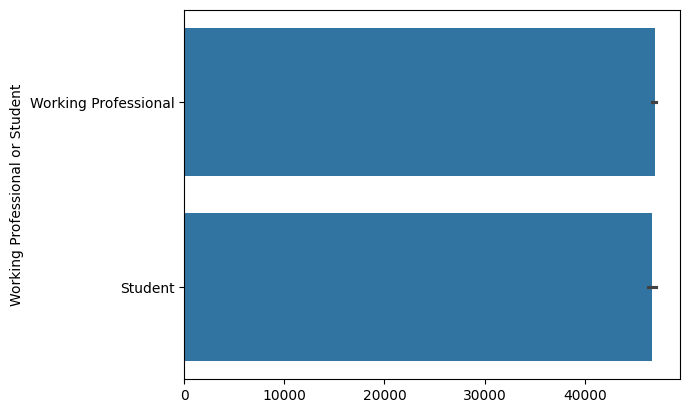

In [ ]:
sns.barplot(df_test["Working Professional or Student"])

There is about an even amount of both working professionals and students.

Now our next chart will be boxplot of the academic pressure of students.

<Axes: xlabel='Sleep Duration', ylabel='Academic Pressure'>

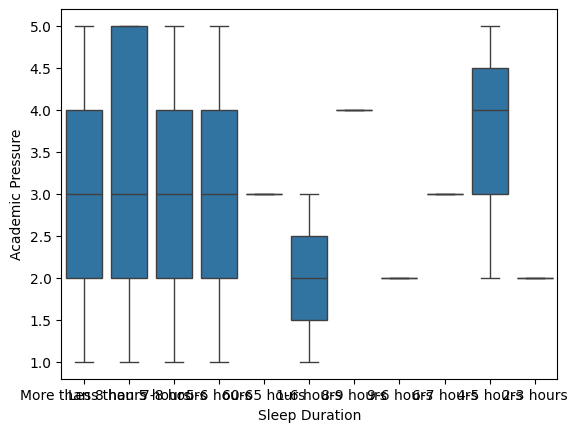

In [26]:
df_students = df_test[df_test["Working Professional or Student"] == "Student"]

sns.boxplot(data=df_students, x="Sleep Duration", y="Academic Pressure")



In [45]:
#Initializing our target variable and features
Overall_target_column = "Depression"

#initializing categorical and numerical columns
numerical_columns = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_columns = df_train.select_dtypes(include=['object', 'str']).columns.tolist()


#printing the target column, numerical columns and categorical columns for verification
print("Target Column: ", Overall_target_column) 
print("Numerical Columns: ", numerical_columns)
print("Categorical Columns: ", categorical_columns)

Target Column:  Depression
Numerical Columns:  ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']
Categorical Columns:  ['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
